## Name: Nafisa Maliat
### Date: 

### Imports & global setup

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Folder where Java saves everything
BASE_DIR = "HALModeling2024Outs"

# Make plots a bit bigger
plt.rcParams["figure.figsize"] = (7, 5)


### Helpers to find & load CSV files

In [2]:
def latest_counts_file(scenario,
                       pattern="TrialRunCounts_*.csv",
                       fallback="TrialRunCounts.csv"):
    """
    Return the path of the latest TrialRunCounts CSV file for a scenario.
    Looks in: HALModeling2024Outs/Scenario<scenario>/
    """
    folder = os.path.join(BASE_DIR, f"Scenario{scenario}")
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Scenario folder does not exist: {folder}")

    # All files like TrialRunCounts_20260203_123456.csv
    candidates = sorted(glob.glob(os.path.join(folder, pattern)))

    if candidates:
        return candidates[-1]  # last = lexicographically latest timestamp

    # Fallback to plain TrialRunCounts.csv (no timestamp)
    fallback_path = os.path.join(folder, fallback)
    if os.path.exists(fallback_path):
        return fallback_path

    raise FileNotFoundError(
        f"No TrialRunCounts CSV found in {folder} "
        f"(looked for {pattern} and {fallback})"
    )


def load_counts_for_scenario(scenario):
    """
    Load the TrialRunCounts file for a given scenario into a DataFrame.
    """
    path = latest_counts_file(scenario)
    print(f"Loading {path}")
    df = pd.read_csv(path)
    return df


### Plot clone counts for each scenario

Loading HALModeling2024Outs/ScenarioControl/TrialRunCounts_20260415_082722.csv


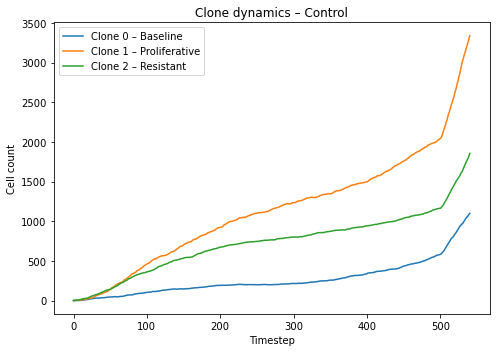

Loading HALModeling2024Outs/ScenarioMRT200/TrialRunCounts_20260415_081057.csv


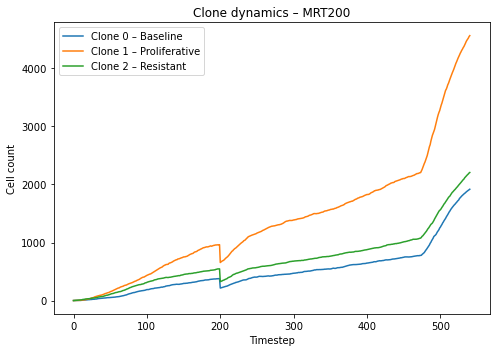

Loading HALModeling2024Outs/ScenarioMRT400/TrialRunCounts_20260415_080823.csv


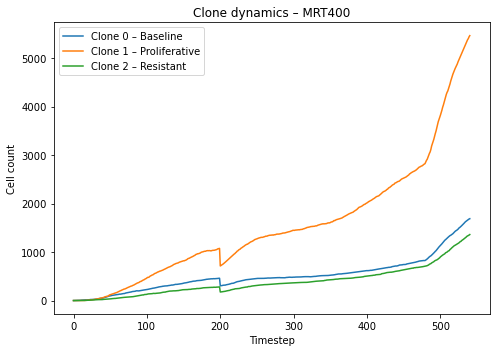

Loading HALModeling2024Outs/ScenarioMRT600/TrialRunCounts_20260415_081357.csv


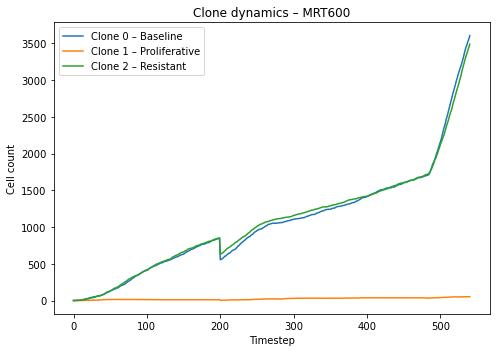

Loading HALModeling2024Outs/ScenarioBB5/TrialRunCounts_20260415_082924.csv


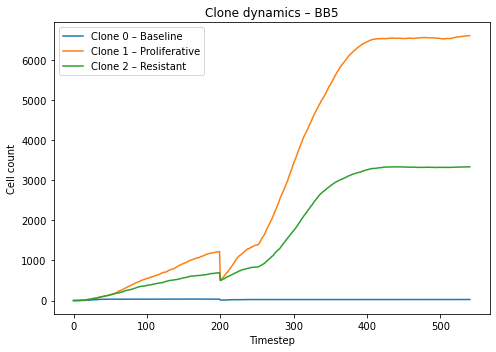

Loading HALModeling2024Outs/ScenarioBB10/TrialRunCounts_20260415_082940.csv


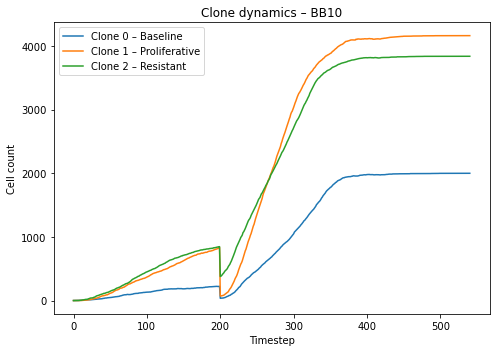

Loading HALModeling2024Outs/ScenarioBB15/TrialRunCounts_20260415_082959.csv


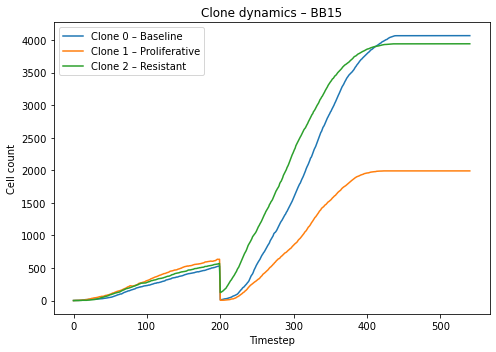

Loading HALModeling2024Outs/ScenarioMB180/TrialRunCounts_20260415_081706.csv


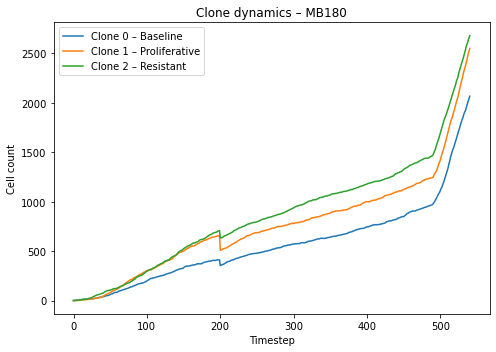

Loading HALModeling2024Outs/ScenarioMB350/TrialRunCounts_20260415_082234.csv


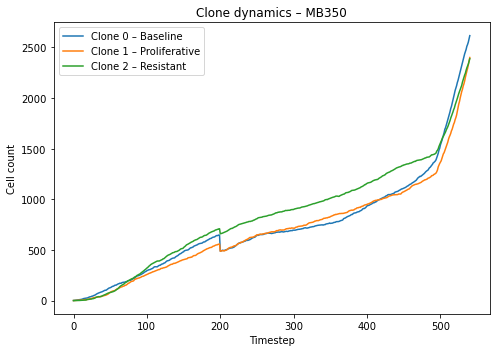

In [3]:
def plot_clone_counts(df, scenario_label=None):
    """
    Plot absolute counts of each clone over time for ONE scenario.
    Assumes columns: Timestep, TumorClone0, TumorClone1, TumorClone2
    """
    if scenario_label is None:
        scenario_label = "Scenario"

    t = df["Timestep"]
    c0 = df["TumorClone0"]
    c1 = df["TumorClone1"]
    c2 = df["TumorClone2"]

    plt.figure()
    plt.plot(t, c0, label="Clone 0 – Baseline")
    plt.plot(t, c1, label="Clone 1 – Proliferative")
    plt.plot(t, c2, label="Clone 2 – Resistant")

    plt.xlabel("Timestep")
    plt.ylabel("Cell count")
    plt.title(f"Clone dynamics – {scenario_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Usage:

df_control = load_counts_for_scenario("Control")
plot_clone_counts(df_control, "Control")

df_mrt200 = load_counts_for_scenario("MRT200")
plot_clone_counts(df_mrt200, "MRT200")

df_mrt400 = load_counts_for_scenario("MRT400")
plot_clone_counts(df_mrt400, "MRT400")

df_mrt600 = load_counts_for_scenario("MRT600")
plot_clone_counts(df_mrt600, "MRT600")

df_bb5 = load_counts_for_scenario("BB5")
plot_clone_counts(df_bb5, "BB5")

df_bb10 = load_counts_for_scenario("BB10")
plot_clone_counts(df_bb10, "BB10")

df_bb15 = load_counts_for_scenario("BB15")
plot_clone_counts(df_bb15, "BB15")

df_mb180 = load_counts_for_scenario("MB180")
plot_clone_counts(df_mb180, "MB180")

df_mb350 = load_counts_for_scenario("MB350")
plot_clone_counts(df_mb350, "MB350")

### Plot clone FRACTIONS for ONE scenario

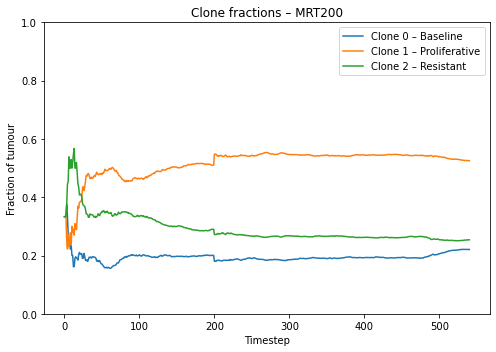

In [4]:
def plot_clone_fractions(df, scenario_label=None):
    """
    Plot the fraction of the tumour occupied by each clone over time.
    Good for seeing clonal competition / selection.
    """
    if scenario_label is None:
        scenario_label = "Scenario"

    t = df["Timestep"]

    total = df["TumorClone0"] + df["TumorClone1"] + df["TumorClone2"]
    eps = 1e-9
    f0 = df["TumorClone0"] / (total + eps)
    f1 = df["TumorClone1"] / (total + eps)
    f2 = df["TumorClone2"] / (total + eps)

    plt.figure()
    plt.plot(t, f0, label="Clone 0 – Baseline")
    plt.plot(t, f1, label="Clone 1 – Proliferative")
    plt.plot(t, f2, label="Clone 2 – Resistant")

    plt.ylim(0, 1)
    plt.xlabel("Timestep")
    plt.ylabel("Fraction of tumour")
    plt.title(f"Clone fractions – {scenario_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Usage:
plot_clone_fractions(df_mrt200, "MRT200")


### Total tumour across scenarios

Loading HALModeling2024Outs/ScenarioControl/TrialRunCounts_20260415_082722.csv
Loading HALModeling2024Outs/ScenarioBB5/TrialRunCounts_20260415_082924.csv
Loading HALModeling2024Outs/ScenarioBB10/TrialRunCounts_20260415_082940.csv
Loading HALModeling2024Outs/ScenarioBB15/TrialRunCounts_20260415_082959.csv
Loading HALModeling2024Outs/ScenarioMRT200/TrialRunCounts_20260415_081057.csv
Loading HALModeling2024Outs/ScenarioMRT400/TrialRunCounts_20260415_080823.csv
Loading HALModeling2024Outs/ScenarioMRT600/TrialRunCounts_20260415_081357.csv
Loading HALModeling2024Outs/ScenarioMB180/TrialRunCounts_20260415_081706.csv
Loading HALModeling2024Outs/ScenarioMB350/TrialRunCounts_20260415_082234.csv


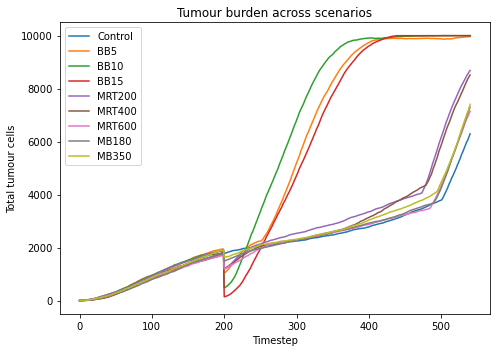

In [5]:
def plot_total_tumour_across_scenarios(scenario_list):
    """
    For each scenario in scenario_list, plot total tumour cells vs timestep
    on the same figure.
    Example: ["Control", "BB5", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]
    """
    plt.figure()

    for scen in scenario_list:
        try:
            df = load_counts_for_scenario(scen)
        except FileNotFoundError as e:
            print(e)
            continue

        t = df["Timestep"]
        total = df["TumorCells"]  
        plt.plot(t, total, label=scen)

    plt.xlabel("Timestep")
    plt.ylabel("Total tumour cells")
    plt.title("Tumour burden across scenarios")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Usage:
scenarios = ["Control", "BB5", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]
plot_total_tumour_across_scenarios(scenarios)


### Resistant clone fraction across scenarios

Loading HALModeling2024Outs/ScenarioControl/TrialRunCounts_20260415_082722.csv
Loading HALModeling2024Outs/ScenarioBB5/TrialRunCounts_20260415_082924.csv
Loading HALModeling2024Outs/ScenarioBB10/TrialRunCounts_20260415_082940.csv
Loading HALModeling2024Outs/ScenarioBB15/TrialRunCounts_20260415_082959.csv
Loading HALModeling2024Outs/ScenarioMRT200/TrialRunCounts_20260415_081057.csv
Loading HALModeling2024Outs/ScenarioMRT600/TrialRunCounts_20260415_081357.csv
Loading HALModeling2024Outs/ScenarioMB180/TrialRunCounts_20260415_081706.csv
Loading HALModeling2024Outs/ScenarioMB350/TrialRunCounts_20260415_082234.csv


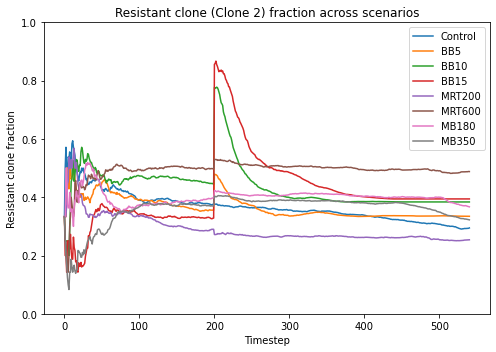

In [6]:
def plot_resistant_fraction_across_scenarios(scenario_list):
    """
    For each scenario, plot the fraction of the tumour that is Clone 2 (resistant)
    over time on the same figure.
    """
    plt.figure()

    for scen in scenario_list:
        try:
            df = load_counts_for_scenario(scen)
        except FileNotFoundError as e:
            print(e)
            continue

        t = df["Timestep"]
        total = df["TumorClone0"] + df["TumorClone1"] + df["TumorClone2"]
        eps = 1e-9
        frac_resistant = df["TumorClone2"] / (total + eps)

        plt.plot(t, frac_resistant, label=scen)

    plt.ylim(0, 1)
    plt.xlabel("Timestep")
    plt.ylabel("Resistant clone fraction")
    plt.title("Resistant clone (Clone 2) fraction across scenarios")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Usage:
scenarios = ["Control", "BB5", "BB10", "BB15", "MRT200", "MRT600", "MB180", "MB350"]
plot_resistant_fraction_across_scenarios(scenarios)
